# Anuario de Aforos: seleccionar estaciones
***

***Autor:** Jesús Casado Rodríguez*<br>
***Fecha:** 06-03-2026*<br>

**Introducción:**<br>
En este _notebook_ se analizan los datos del *Anuario de Aforos* y se hace una selección de las estaciones a incluir en CAMELS-ES en base a:

1. Disponibilidad mínima de datos en la serie de caudal.
2. Series de caudal con mínima alteración del régimen natural, puesto que las series claramente influidas por embalses no son propicias para el modelado.
3. Eliminar estaciones que por cercanía están altamente correlacionadas.

**Por hacer**:


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
# import cartopy.crs as ccrs
# import cartopy.feature as cf
from tqdm.notebook import tqdm
from pathlib import Path

from camels_es.config import Config
from camels_es.anuario_aforos import extraer_estaciones, extraer_caudal_estaciones, extraer_embalses, periodo_estudio
from camels_es.plots import plot_stations, create_index, plot_discharge_timeseries

## Configuración

In [2]:
cfg = Config('../config.yml')

## Estaciones

### Anuario de Aforos

nº de estaciones en el   Cantabrico:	  95
nº de estaciones en el        Duero:	 210
nº de estaciones en el         Ebro:	 290
nº de estaciones en el Galicia costa:	  51
nº de estaciones en el Guadalquivir:	 117
nº de estaciones en el     Guadiana:	 145
nº de estaciones en el        Jucar:	 111
nº de estaciones en el     Miño-sil:	  86
nº de estaciones en el       Segura:	  82
nº de estaciones en el         Tajo:	 207

nº total de estaciones:			1394
nº de estaciones en servicio:		 918


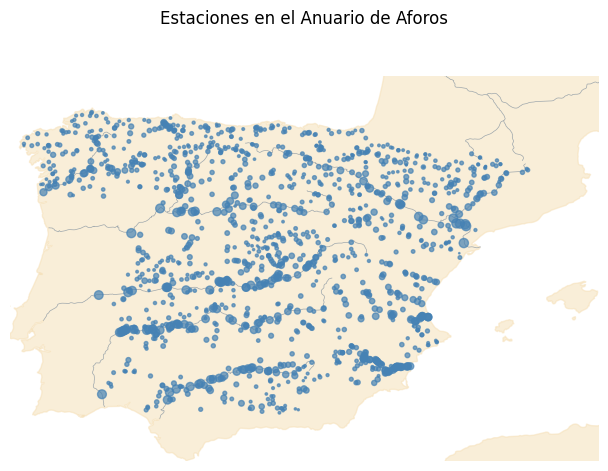

In [3]:
# identificar demarcaciones hidrográficas
cuencas = {dir.stem: dir for dir in cfg.path_in.iterdir() if dir.is_dir() &  (dir.stem not in ['estaciones', 'GIS', 'timeseries'])}

# extraer estaciones del Anuario de Aforos
if 'estaciones' in locals():
    del estaciones
for cuenca, folder in cuencas.items():
    stns = extraer_estaciones(
        folder / 'estaf.csv',
        min_area=cfg.area_min, 
        max_area=cfg.area_max, 
        years=cfg.min_años, 
        epsg=cfg.crs)
    stns['cuenca'] = cuenca
    if 'estaciones' in locals():
        estaciones = pd.concat((estaciones, stns))
    else:
        estaciones = stns
    print('nº de estaciones en el {0:>12}:\t{1:>4}'.format(cuenca.capitalize(), stns.shape[0]))
estaciones.sort_index(axis=0, inplace=True)
estaciones.index = estaciones.index.astype(int)

# mapa de las estaciones
plot_stations(
    estaciones.geometry, 
    area=estaciones.suprest, 
    extent=[-9.5, 3.5, 36, 44.5],
    title=f'Estaciones en el Anuario de Aforos',
    save=cfg.path_plots / 'estaciones.jpg'
)

print('\nnº total de estaciones:\t\t\t{0:>4}'.format(estaciones.shape[0]))
print('nº de estaciones en servicio:\t\t{0:>4}'.format(estaciones.loc[estaciones.serv == 1].shape[0]))

### MITECO

In [4]:
# cargar tabla de atributos de las estaciones
# est_miteco = pd.read_csv(
#     cfg.path_in / 'estaciones' / 'Situac 4_Rio.csv', 
#     index_col='COD_HIDRO', 
#     encoding='latin1', 
#     sep=';',
#     decimal=','
#     )
est_miteco = pd.read_csv(
    cfg.path_in / 'estaciones' / 'Situac_4_Rio_rev.csv',
    encoding='latin1',
    index_col='COD_HIDRO'
    )
est_miteco.columns = est_miteco.columns.str.lower()
est_miteco.rename(
    columns={'regimen_rio': 'regimen', 'sistema_explo': 'sistema'}, 
    inplace=True
    )
print('Nº estaciones:\t{0}\nNº atributos:\t{1}'.format(*est_miteco.shape))

# adaptar campo "regimen"
cols = ['rio', 'regimen', 'sistema']
for col in cols:
    est_miteco[col] = est_miteco[col].str.lower()
    est_miteco.loc[est_miteco[col].isnull(), col] = pd.NA
est_miteco.regimen = est_miteco.regimen.replace({
    'muy modificado': 'alterado',
    '-': 'desconocido',
    pd.NA: 'desconocido'
    })

# añadir campos 'rio' y 'regimen' a estaciones
ids = estaciones.index.intersection(est_miteco.index)
estaciones.loc[ids, cols] = est_miteco.loc[ids, cols]

del est_miteco

Nº estaciones:	1491
Nº atributos:	39


In [5]:
# sns.histplot(estaciones.naa, binwidth=1);

In [6]:
# sns.histplot(estaciones.suprest);
# plt.xscale('log')

## Embalses

  0%|          | 0/10 [00:00<?, ?it/s]

nº de embalses en el   Cantabrico:	 22
nº de embalses en el        Duero:	 31
nº de embalses en el         Ebro:	 95
nº de embalses en el Galicia costa:	  8
nº de embalses en el Guadalquivir:	 62
nº de embalses en el     Guadiana:	 35
nº de embalses en el        Jucar:	 35
nº de embalses en el     Miño-sil:	 35
nº de embalses en el       Segura:	 18
nº de embalses en el         Tajo:	 57

nº total de embalses:			398
nº de embalses en servicio:		367


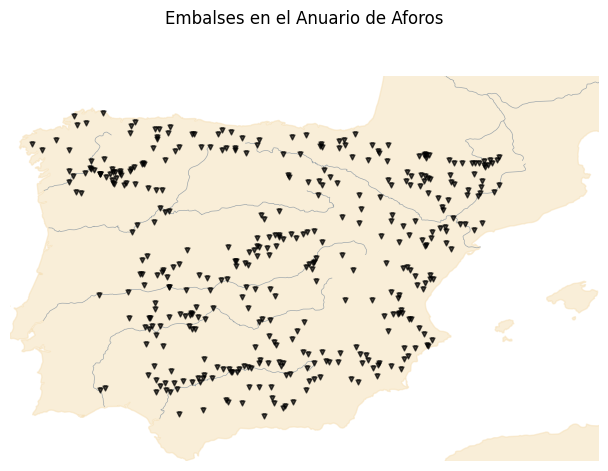

In [7]:
# extraer embalses del Anuario de Aforos
if 'embalses' in locals():
    del embalses
for cuenca in tqdm(cuencas):
    res = extraer_embalses(cfg.path_in / cuenca / 'embalse.csv', epsg=cfg.crs)
    res['cuenca'] = cuenca
    if 'embalses' in locals():
        embalses = pd.concat((embalses, res))
    else:
        embalses = res
    print('nº de embalses en el {0:>12}:\t{1:>3}'.format(cuenca.capitalize(), res.shape[0]))
    del res

# mapa de los embalses
plot_stations(
    embalses.geometry, 
    # area=estaciones.suprest, 
    extent=[-9.5, 3.5, 36, 44.5],
    marker='v',
    color='k',
    title=f'Embalses en el Anuario de Aforos',
    # save=cfg.path_plots / 'embalses.jpg'
)

print('\nnº total de embalses:\t\t\t{0:>3}'.format(embalses.shape[0]))
print('nº de embalses en servicio:\t\t{0:>3}'.format(embalses.loc[embalses.serv == 1].shape[0]))

## Caudal 

In [8]:
# extraer series de caudal del Anuario de Aforos
if 'caudal' in locals():
    del caudal
for cuenca in tqdm(cuencas):
    ids = estaciones[estaciones.cuenca == cuenca].index.to_list()
    q = extraer_caudal_estaciones(
        cfg.path_in / cuenca / 'afliq.csv', 
        indroea=ids, 
        start=cfg.start, 
        end=cfg.end
    )
    if 'caudal' in locals():
        caudal = pd.concat((caudal, q), axis=1)
    else:
        caudal = q
    print('nº de estaciones en las series de caudal del {0:>12}:\t{1:>3} ({2:>4})'.format(cuenca.capitalize(),
                                                                                  q.shape[1],
                                                                                  len(ids)))
caudal.sort_index(axis=1, inplace=True)
caudal.columns = caudal.columns.astype(int)

print('\nnº total de estaciones con serie de caudal:\t\t\t{0:>3} ({1:>4})'.format(caudal.shape[1], len(estaciones)))

  0%|          | 0/10 [00:00<?, ?it/s]

nº de estaciones en las series de caudal del   Cantabrico:	 69 (  95)
nº de estaciones en las series de caudal del        Duero:	196 ( 210)
nº de estaciones en las series de caudal del         Ebro:	252 ( 290)
nº de estaciones en las series de caudal del Galicia costa:	 46 (  51)
nº de estaciones en las series de caudal del Guadalquivir:	 94 ( 117)
nº de estaciones en las series de caudal del     Guadiana:	101 ( 145)
nº de estaciones en las series de caudal del        Jucar:	 55 ( 111)
nº de estaciones en las series de caudal del     Miño-sil:	 65 (  86)
nº de estaciones en las series de caudal del       Segura:	 52 (  82)
nº de estaciones en las series de caudal del         Tajo:	135 ( 207)

nº total de estaciones con serie de caudal:			1065 (1394)


In [9]:
# añadir un campo booleano en 'estaciones' si tiene o no datos de caudal
estaciones['caudal'] = 0
estaciones.loc[caudal.columns, 'caudal'] = 1

In [10]:
# definir el mejor periodo de estudio de cada estación
estaciones[['inicio', 'fin']] = periodo_estudio(caudal, cfg.disponibilidad, cfg.min_años)

# estaciones con el mínimo de nº de años
mask_años = ~estaciones.inicio.isnull()
print('nº total de estaciones con {0} años de caudal:\t\t{1}'.format(cfg.min_años, mask_años.sum()))#caudal.shape[1]))

nº total de estaciones con 4 años de caudal:		951


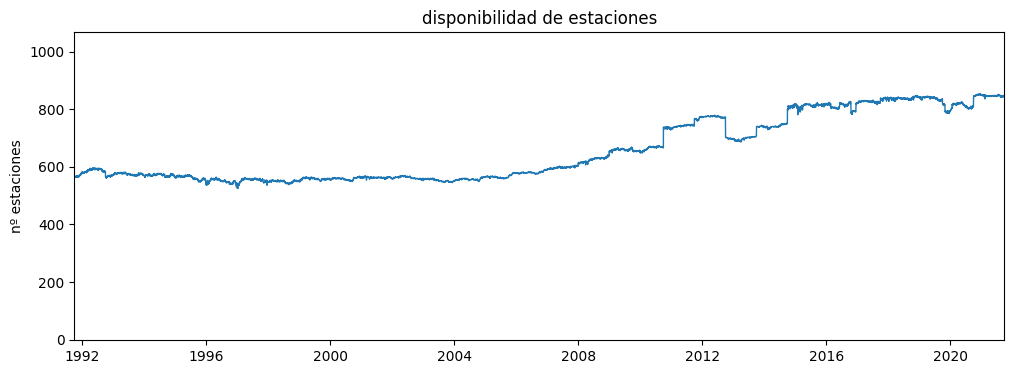

In [11]:
# gráfico de la disponibilidad de estaciones
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(caudal.shape[1] - caudal.isnull().sum(axis=1), lw=1)
ax.set(
    ylim=(-2, caudal.shape[1] + 2),
      xlim=(cfg.start, cfg.end), 
      ylabel='nº estaciones'
      )
ax.axhline(estaciones.shape[0], c='k', lw=.5)
ax.set_title('disponibilidad de estaciones');

plt.savefig(cfg.path_plots / 'disponibilidad.jpg', dpi=300, bbox_inches='tight');

### Hidrogramas

In [20]:
regimenes = {
    'desconocido': 'dimgrey',
    'natural': 'steelblue',
    'alterado': 'indianred',
    'regulado': 'gold',
}

estaciones_sel = []
index_glob = []
estaciones['link'] = ''
gh_pages = Path(os.getcwd()).parent.parent / 'docs'
for cuenca in tqdm(cuencas, desc='Cuencas'):

    # crear estructura de archivos
    path_basin = gh_pages / cuenca.title()
    index_glob.append((f'./{cuenca.title()}/index.html', cuenca.capitalize()))
    
    index_basin = []

    # filtrar estaciones en la cuenca con datos de caudal
    stns_basin = estaciones.loc[(estaciones.cuenca == cuenca) & (estaciones.caudal == 1)]

    # iterar por sistemas de explotación
    sistemas = list(set(stns_basin.sistema))
    pbar_sys = tqdm(sorted(sistemas), total=len(sistemas), desc='Sistema', leave=False)
    for sistema in pbar_sys:
        # índice y ruta del sistema
        index_sys = []
        path_sys = path_basin / sistema.title()
        path_plots = path_sys / 'plots'
        path_plots.mkdir(parents=True, exist_ok=True)

        # actualizar índice de la demarcación
        index_basin.append((f'./{sistema.title()}/index.html', sistema.capitalize()))
        
        # crear los hidrogramas
        stns = stns_basin.loc[stns_basin.sistema == sistema]
        stns.sort_index(inplace=True)
        pbar = tqdm(enumerate(stns.iterrows()), total=len(stns), desc='Estaciones', leave=False)
        for i, (id, attrs) in pbar:
            if id not in caudal.columns:
                continue

            # crear el hidrograma en HTML
            ts = caudal[id]
            ts = ts.loc[ts.first_valid_index():ts.last_valid_index()]
            title = '{0} - {1} ({2})'.format(id, attrs.lugar.capitalize(), attrs.rio.capitalize())
            file = f'./plots/{id}.html'
            plot_discharge_timeseries(
                ts, 
                area=attrs.suprest,
                title=title,
                regime=attrs.regimen,
                c=regimenes[attrs.regimen],
                save=path_sys / file,
            )

            # guardar el archivo en el índice y el shp
            index_sys.append((file, title))
            # stns_basin.loc[id, 'link'] = 'file:///' + str(Path('C:/') / path_sys.relative_to('/mnt/c/') / file)
        
        # crear índice del sistema de explotación
        create_index(
            path_sys, 
            title=sistema.lower(), 
            header=sistema.title(), 
            index=index_sys,
            target='_self',
            parent='Sistemas'
            )
    
    # crear índice de la cuenca
    create_index(
        path_basin, 
        title=cuenca.lower(), 
        header=cuenca.title(), 
        index=index_basin, 
        target='_self',
        parent='Cuencas')

    estaciones_sel.append(stns_basin)

# guardar shapefile
estaciones_sel = pd.concat(estaciones_sel, axis=0)
estaciones_sel.to_file(cfg.path_GIS / f'estaciones_caudal.shp')

# crear índice global
create_index(gh_pages, title='camels-es', header='Cuencas', index=index_glob, target='_self')

Cuencas:   0%|          | 0/10 [00:00<?, ?it/s]

Sistema:   0%|          | 0/22 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/1 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/1 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/2 [00:00<?, ?it/s]

...

Estaciones:   0%|          | 0/14 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/15 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/89 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/11 [00:00<?, ?it/s]

Estaciones:   0%|          | 0/6 [00:00<?, ?it/s]

In [19]:
path_sys, path_basin, path_plots

(PosixPath('/home/casadoj/Git/CAMELS-ES/TAJO/ÁRRAGO'),
 PosixPath('/home/casadoj/Git/CAMELS-ES/TAJO'),
 PosixPath('/home/casadoj/Git/CAMELS-ES/TAJO/ÁRRAGO/plots'))

***

In [ ]:
from typing import Literal, List, Optional, Tuple

def create_index(
        path: str, 
        title: str, 
        header: str, 
        index: List[Tuple],
        target: Literal['_self', '_blank'] = '_self',
        parent: Optional[str] = None
    ):
    """
    Crea un archivo 'index.html' en la ruta definida que permite el acceso a gráficos de las estaciones

    Parámetros:
    -----------
    path: str
        Ruta donde se guardará el archivo 'index.html'
    title: str
        Nombre que aparecerá en la pestaña del navegador
    header: str
        Título de la página
    index: list of tuples
        Lista de pares de valores: etiqueta que aparece en la página, enlace al archivo
    target: str
        Si se quiere que se abra una nueva pestaña ('_blank') o en la misma ('_self')
    parent: str
        Nombre de la página superior (en caso de existir)
    """
    

    # CSS for a modern, clean look
    css = """
    <style>
        body { 
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; 
            line-height: 1.6; 
            color: #333; 
            max-width: 800px; 
            margin: 40px auto; 
            padding: 0 20px;
            background-color: #f8f9fa;
        }
        h1 { color: #2c3e50; border-bottom: 2px solid steelblue; padding-bottom: 10px; }
        .back-link { display: inline-block; margin-bottom: 20px; color: steelblue; text-decoration: none; font-weight: bold; }
        .back-link:hover { text-decoration: underline; }
        ul { list-style: none; padding: 0; }
        li { background: white; margin: 5px 0; padding: 10px; border-radius: 5px; box-shadow: 0 2px 4px rgba(0,0,0,0.05); transition: 0.2s; }
        li:hover { transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,0,0,0.1); }
        a.station-link { text-decoration: none; color: #2980b9; display: block; width: 100%; }
        a.station-link:hover { color: steelblue; }
    </style>
    """

    file = path / "index.html"
    with open(file, "w") as f:
        f.write("<!DOCTYPE html>\n<html>\n<head>\n")
        f.write(f"<meta charset='utf-8'>\n<title>{title}</title>\n{css}\n</head>\n")
        f.write("<body>\n")

        # link to parent folder
        if parent:
            f.write(f"<a href='../index.html' class='back-link'>← {parent}</a>\n")

        # header
        f.write(f"<h1>{header}</h1>\n")

        # list of links
        f.write("<ul>\n")
        for link, label in index:
            f.write(f"  <li><a class='station-link' href='{link}' target='{target}'>{label}</a></li>\n")
        f.write("</ul>\n</body>\n</html>")

In [ ]:
create_index(
        path_basin, 
        title=cuenca.lower(), 
        header=cuenca.title(), 
        index=index_basin, 
        target='_self',
        parent='Cuencas')

In [ ]:
plot_discharge_timeseries(
    ts, 
    area=attrs.suprest,
    title=title,
    regime=attrs.regimen,
    c=regimenes[attrs.regimen],
    save=path_sys / file,
)

In [ ]:
path_sys/file

***

In [ ]:
del plot_discharge_timeseries

In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from typing import Optional

def plot_html(
    ts: pd.Series, 
    area: float,
    regime: Optional[str] = None,
    save: Optional[str] = None, 
    **kwargs
    ):

    # Extract keywords
    c = kwargs.get('c', 'steelblue')
    title = kwargs.get('title', None)
    prev_link = kwargs.get('prev_link', None)
    next_link = kwargs.get('next_link', None)
    parent_link = ""

    # 1. Compute hydrological signatures
    ar = annual_runoff(ts, area)
    _, bfi = baseflow_index(ts)
    fi = flashiness_index(ts)
    fdc, slope = slope_fdc(ts)
    signature_text = (
        f"<b>Catchment Properties</b><br>"
        f"Area: {area:.0f} km²<br>"
        f"Regime: {regime}<br><br>"
        f"<b>Hydrological Signatures</b><br>"
        f"Baseflow Index: {bfi:.2f}<br>"
        f"Flashiness Index: {fi:.2f}<br>"
        f"Slope Flow Duration Curve: {slope:.2f}<br>"
        f"Annual Runoff: {ar:.0f} mm"
    )
    signature_annotation = dict(
        text=signature_text,
        xref="paper", yref="paper",
        x=1.02, xanchor="left",
        y=1, yanchor="top",
        showarrow=False,
        align="left",
        font=dict(size=12),
        bgcolor="rgba(255, 255, 255, 0.9)",
    )

    # 2. Create Subplots 
    fig = make_subplots(
        rows=1, cols=2, 
        shared_yaxes=True, 
        column_widths=[0.7, 0.25], 
        horizontal_spacing=0.03,
        subplot_titles=("Hydrograph", "Flow Duration Curve")
    )

    # 3. Add traces
    fig.add_trace(go.Scatter(x=ts.index, y=ts.values, line=dict(color=c, width=1)), row=1, col=1)
    fig.add_trace(go.Scatter(x=fdc.index * 100, y=fdc.values, line=dict(color=c, width=2)), row=1, col=2)    

    # helper to add buttons as annotations
    nav_annotations = []
    y = -0.25
    # if prev_link:
    #     nav_annotations.append(dict(
    #         text=f"<a href='{prev_link}'>  ◄ Previous  </a>",
    #         xref="paper", yref="paper", x=0, y=y, 
    #         xanchor='left', yanchor='top', 
    #         showarrow=False,
    #         font=dict(size=13, color="black"), 
    #         bgcolor="white", bordercolor="grey", borderwidth=1
    #     ))    
    # nav_annotations.append(dict(
    #     text=f"<a href='../index.html' target='_self'>  ☰ Index  </a>",
    #     xref="paper", yref="paper", x=0.5, y=y, 
    #     xanchor='center', yanchor='top', 
    #     showarrow=False,
    #     font=dict(size=13, color="black"), 
    #     bgcolor="white", bordercolor="grey", borderwidth=1
    # ))
    # if next_link:
    #     nav_annotations.append(dict(
    #         text=f"<a href='{next_link}'>  Next ►  </a>",
    #         xref="paper", yref="paper", x=1, y=y, 
    #         xanchor='right', yanchor='top', 
    #         showarrow=False,
    #         font=dict(size=13, color="black"), 
    #         bgcolor="white", bordercolor="grey", borderwidth=1
    #     ))
    
    # 4. Update Layout
    fig.update_layout(
        title_text=f"<b>{title if title else ''}</b>", # Global figure title
        title_x=0.5,                                   # Center the title
        margin=dict(l=50, r=250, t=100, b=200),         # LARGE right margin (250px)
        template="plotly_white",
        height=550,
        showlegend=False,
        # annotations=nav_annotations + [signature_annotation],
        annotations=signature_annotation,
        updatemenus=[
            dict(
                type="buttons",
                direction="down",
                active=0,
                x=0.0, 
                y=1.25,
                buttons=[
                    dict(label="Linear Scale", method="relayout", 
                         args=[{"yaxis.type": "linear", "yaxis2.type": "linear"}]),
                    dict(label="Log Scale", method="relayout", 
                         args=[{"yaxis.type": "log", "yaxis2.type": "log"}]),
                ],
            )
        ]
    )

    # Update Axes Titles
    fig.update_yaxes(title_text="Discharge (m³/s)", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Exceedance Prob. (%)", row=1, col=2)

    if save:
        fig.write_html(str(save))
        nav = """
            <div style="text-align:center; margin-top:20px;">
                <a href="../index.html" 
                style="padding:6px 12px; border:1px solid grey; background:white;
                        text-decoration:none; font-family:sans-serif;">
                ☰ Index
                </a>
            </div>
            """

    with open(save, "w") as f:
        f.write(f"""<html>\n<body>{html}{nav}</body>\n</html>""")
    else:
        fig.show()

***

In [ ]:
from camels_es.signatures import *

In [ ]:
id = 1297

In [ ]:
ts = caudal[id]
ts = ts.loc[ts.first_valid_index():ts.last_valid_index()]
plot_html(
    ts, 
    area=estaciones.loc[id, 'suprest'],
    prev_link='1296.html',
    next_link='1302.html',
    )

In [ ]:
fig, ax = plt.subplots()
ax.plot(caudal[id])
ax.set_yscale('log')

In [ ]:
# # hidrogramas de cada estación
# # plt.switch_backend('Agg')
# for stn in tqdm(estaciones[mask_años].index):
    
#     # inicio y fin de la serie de esta estación
#     inicio = datetime(int(estaciones.loc[stn, 'inicio']), 1, 1)
#     fin = datetime(int(estaciones.loc[stn, 'fin']) + 1, 1, 1)

#     # hidrogromas
#     path = cfg.path_out / estaciones.loc[stn, 'cuenca'] / 'plots' 
#     path.mkdir(parents=True, exist_ok=True)
#     file = path / f'{stn:04}.jpg'
#     title = '{0} - {1} ({2} km2)'.format(stn, *estaciones.loc[stn, ['lugar', 'suprest']])
#     plot_caudal(
#         caudal.loc[inicio:fin, stn], 
#         title=title, 
#         save=file
#         )

## Selección de estaciones

***

In [ ]:
# estaciones a eliminar porque la serie está alterada por embalses
# las estaciones comentadas son etaciones dudosas
eliminar = {'CANTABRICO': ['1164','1175', '1186', '1196', '1207', '1215', '1237',
                           '1264', '1274', '1276', '1294', '1335', '1358', '1359',
                           '1425', '1446', '1588', '1805'],
            'DUERO': ['2001', '2002', '2004', '2010', '2011', '2018', '2019', '2020',
                      '2021', '2023', '2024', '2032', '2040', '2042', '2044', '2048', '2052', '2066',
                      '2073', '2075', '2078', '2084', '2087', '2088', '2091', '2094',
                      '2099', '2102', '2103', '2108', '2109', '2111', '2112', '2124', '2129',
                      '2133', '2134', '2135', '2137', '2140', '2148', '2149', '2161',
                      '2162', '2718', '2719'],
            #'2041', '2050', '2061', '2062', '2074'
            'EBRO': ['9001', '9005', '9007', '9008', '9010', '9012', '9013', '9014',
                     '9015', '9017', '9022', '9024', '9025', '9026', '9027', '9031',
                     '9032', '9034', '9035', '9036', '9042', '9047', '9048', '9049',
                     '9055', '9056', '9057', '9058', '9059', '9060', '9065', '9066', '9076', '9083',
                     '9084', '9087', '9094', '9096', '9097', '9099', '9100', '9101', '9105',
                     '9106', '9111', '9115', '9118', '9122', '9123', '9124', '9125',
                     '9126', '9127', '9137', '9142', '9145', '9147', '9155', '9161',
                     '9163', '9168', '9174', '9176', '9185', '9186', '9190', '9191', '9192',
                     '9193', '9201', '9209', '9216', '9225', '9229', '9230', '9231', '9250', '9250',
                     '9251', '9255', '9258', '9260', '9264', '9266', '9273', '9277', '9278', '9290',
                     '9292', '9307', '9315', '9319'],
            #, '9153', '9291', '9317'
            'GALICIA': ['1455', '1514', '1519', '1550', '1564'],
            'GUADALQUIVIR': ['5001', '5004', '5014', '5019', '5020', '5024', '5025',
                             '5027', '5041', '5042', '5048', '5077', '5081', '5082', '5084', '5090',
                             '5095', '5127', '5140', '5147', '5144', '5150'],
             # '5045', '5050', '5138', '5140', ''
            'GUADIANA': ['4004', '4009', '4013', '4030', '4105', '4201', '4202', '4203', '4207', '4209',
                         '4212', '4214', '4904'],
            # , ''
            'JUCAR': ['8005', '8015', '8022', '8025', '8027', '8032', '8036', '8042', '8071', '8074', '8089',
                      '8092', '8093', '8096', '8107', '8112', '8119', '8129', '8130', '8137', '8138', '8139',
                      '8140', '8144', '8145', '8147', '8148', '8153'],
                      #, '8028', '8032', '8060', '8104', '8120'
            'MINHO': ['1631', '1639', '1640', '1642', '1719', '1831'],
            'SEGURA': ['7001', '7003', '7004', '7006', '7013', '7016', '7018', '7029', '7030', '7055',
                       '7057', '7062', '7063', '7064', '7112', '7121', '7124', '7137', '7164', '7167', '7628'],
            # , '7112', '7117', '7121', '7165', ''
            'TAJO': ['3003', '3031', '3041', '3048', '3054', '3060', '3061', '3063', '3067', '3070', '3080',
                     '3082', '3147', '3149', '3153', '3158', '3162', '3164', '3172', '3173', '3177', '3183',
                     '3187', '3188', '3230', '3232', '3233', '3237', '3238', '3240', '3243', '3248',
                     '3251', '3254', '3255', '3258', '3259', '3270', '3271', '3273', '3281', '3904',
                      '3940'],
            #'3012', '3014', '3062, '3169', '3174', '3175', '3220', '3233', 
            #'3250', '3251', '3253', '3255', '3256', '3268', '3276', '3278', '3279', ''
            }

In [ ]:
# crear campo booleano con las estaciones seleccionadas
estaciones['sel'] = (~estaciones.inicio.isnull()).astype(int)
for cuenca in cuencas:
    estaciones.loc[eliminar[cuenca], 'sel'] = 0

print('nº de estaciones seleccionadas:\t{0}'.format((estaciones.sel == 1).sum()))

In [ ]:
# estaciones a eliminar porque hay otra estación cercana
eliminar2 = {'CANTABRICO': ['1303'],
            'DUERO': ['2076', '2070', '2068', '2117', '2710', '2123', '2097', '2085', ],
            'EBRO': ['9153', '9046', '9091', '9043', '9268', '9018', '9313', '9253', '9329', '9050'],
            'GALICIA': ['1440', '1483'],
            'GUADALQUIVIR': ['5076', '5128', '5080'],
            'GUADIANA': [],
            'JUCAR': ['8030'],
            'MINHO': ['1644', '1645','1626', '1625', '1628', '1621', '1607', '1608', '1617', '1754',
                      '1727', '1722', '1724'],
            'SEGURA': ['7165', '7117', '7129'],
            'TAJO': ['3194', '3102', '3159'],
            }

In [ ]:
for cuenca in cuencas:
    estaciones.loc[eliminar2[cuenca], 'sel'] = 0

print('nº de estaciones seleccionadas:\t{0}'.format((estaciones.sel == 1).sum()))

## Exportar resultados

In [ ]:
# exportar todas las estaciones juntas
estaciones.to_file(cfg.path_GIS / 'estaciones.shp', driver='ESRI Shapefile', index=True)

# exportar las series de caudal
caudal.to_parquet(cfg.path_out / 'caudal.parquet')

# exportar todos los embalses juntos
embalses.rename(columns={'nom_embalse': 'nombre'}, inplace=True)
embalses.to_file(cfg.path_GIS / 'embalses.shp', driver='ESRI Shapefile', index=True)

In [ ]:
caudal.shape

In [ ]:
caudal.head()